In [1]:
import pandas as pd
import numpy as np
import subprocess
from tqdm import tqdm

In [3]:
def get_lr_hippocampus_vol(stats_file):
    """
    Given a stats file from freesurfer, get the left and right hippocampus volumes
    """

    with open(stats_file, 'r') as f:
        lines = f.readlines()
        lines = [x.strip() for x in lines]
        #get the left and right hippocampal volumes estimated from freesurfer
        left = [y for y in [x for x in lines if 'Left-Hippocampus' in x][0].split(' ') if y != ''][3]
        right = [y for y in [x for x in lines if 'Right-Hippocampus' in x][0].split(' ') if y != ''][3]

    return float(left), float(right)

def parse_aseg_stats_file(stats_file):

    def parse_subregion_line(line):

        subparts = [y for y in line.split(' ') if y != '']
        #get the subregion name and the volume
        subregion_name = subparts[4]
        subregion_vol = subparts[3]
        return (subregion_name, float(subregion_vol))

    def parse_global_line(line):
        
        #get the global volume and name
        #remove the "# Measure" part of the line at the beginning
        csv_line = line.split('# Measure')[-1]
        #split by the comma
        splits = csv_line.split(',')
        #get the name and volume
        name = splits[1].strip()
        vol = splits[3].strip()
        return (name, float(vol))
        

    with open(stats_file, 'r') as f:
        lines = f.readlines()
        lines = [x.strip() for x in lines]
        
        #get all the lines that begin with "# Measure". These will be the global volumes
        global_vol_lines = [x for x in lines if x.startswith("# Measure")]
        #get the index of the line that begins with "# ColHeaders". All the lines after this line are the volumes of specific regions
        col_headers_index = [i for i, x in enumerate(lines) if x.startswith("# ColHeaders")][0]
        sub_roi_lines = lines[col_headers_index + 1:]

    #now, we need to parse out the volumes of all the lines into a dictionary
    #create a dictionary to hold the volumes. Populat it
    volumes_dict = {}
    for x in sub_roi_lines:
        k,v = parse_subregion_line(x)
        volumes_dict[k] = v
        #volumes_dict = {k:v for x in sub_roi_lines for k,v in parse_subregion_line(x)}
    #also get the global volumes
    for x in global_vol_lines:
        k,v = parse_global_line(x)
        volumes_dict[k] = v
        #volumes_dict = {k:v for x in global_vol_lines for k,v in parse_global_line(x)}
    #global_volumes_dict = {k:v for x in global_vol_lines for k,v in parse_global_line(x)}

    #combine the two dictionaries
    #combined_dict = {**volumes_dict, **global_volumes_dict}
    return volumes_dict

def freesurfer_succeeded(fs_dir):
    """
    Check if freesurfer succeeded by seeing if the log file contains the string "finished without error"
    """
    cmd = 'cat {}/freesurfer/scripts/recon-all.log | tail -n 20 | grep "finished without error"'.format(fs_dir)
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()
    return res != ''

def collect_segmentation_volumes(fs_dirs):
    """
    Collect the volume estimates from the aseg stats files
    """

    dicts = []

    for fs_dir in tqdm(fs_dirs):
        #get the aseg.stats file
        stats_file = '{}/freesurfer/stats/aseg.stats'.format(fs_dir)
        #get the left and right hippocampus volumes
        #left, right = get_lr_hippocampus_vol(stats_file)
        #instead, get all the aseg stats
        aseg_stats = parse_aseg_stats_file(stats_file)
        
        #get the subject id
        sub = fs_dir.split('/')[-3]
        ses = fs_dir.split('/')[-2]
        fs_dir = fs_dir.split('/')[-1]

        #create the dict
        fs_dict = {'sub': sub, 'ses': ses, 'fs_dir': fs_dir}
        #add all the aseg stats to the dict
        for k, v in aseg_stats.items():
            fs_dict[k] = v

        #append to the list
        dicts.append(fs_dict)
    
    #create the dataframe
    df = pd.DataFrame(dicts)

    return df

def get_server_hippocampus_df(root, server_name):

    cmd = 'find {} -mindepth 3 -maxdepth 3 -name "freesurfer*{}*"'.format(root, server_name)
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip().splitlines()

    #get only the freesurfer directories that succeeded
    print("Checking valid freesurfer directories...")
    valid_fs = [x for x in tqdm(res) if freesurfer_succeeded(x)]
    print("Found {} valid freesurfer directories out of {}".format(len(valid_fs), len(res)))

    #collect the hippocampus volumes
    print("Collecting hippocampus volumes...")
    hippocampus_volumes = collect_segmentation_volumes(valid_fs)

    return hippocampus_volumes

#get all the landman01 stats files
root = '/nfs/masi/kimm58/containerization_data/DLBS_50/derivatives'

#collect_segmentation_volumes(['/nfs/masi/kimm58/containerization_data/DLBS/derivatives/sub-3406/ses-wave1/freesurfer7.2.0_landman01_run-1/'])

landman01_res = get_server_hippocampus_df(root, 'landman01')
hickory_res = get_server_hippocampus_df(root, 'hickory')
beatles_res = get_server_hippocampus_df(root, 'beatles')
goat_res = get_server_hippocampus_df(root, 'GOAT')
#masi-24, masi-26, masi-43, masi-55, MASI-64, mastadon, viselab
masi24_res = get_server_hippocampus_df(root, 'masi-24')
masi26_res = get_server_hippocampus_df(root, 'masi-26')
masi43_res = get_server_hippocampus_df(root, 'masi-43')
masi55_res = get_server_hippocampus_df(root, 'masi-55')
masi64_res = get_server_hippocampus_df(root, 'MASI-64')

viselab_res = get_server_hippocampus_df(root, 'viselab')
#mastadon_res = get_server_hippocampus_df(root, 'mastadon')

Checking valid freesurfer directories...


100%|██████████| 50/50 [00:05<00:00,  9.41it/s]


Found 50 valid freesurfer directories out of 50


100%|██████████| 50/50 [00:01<00:00, 41.18it/s]


Checking valid freesurfer directories...


...

100%|██████████| 50/50 [00:02<00:00, 20.80it/s]


Checking valid freesurfer directories...


100%|██████████| 50/50 [00:06<00:00,  7.20it/s]


Found 50 valid freesurfer directories out of 50


100%|██████████| 50/50 [00:02<00:00, 22.99it/s]


In [33]:
mastadon_res = get_server_hippocampus_df(root, 'mastadon')

Checking valid freesurfer directories...


100%|██████████| 50/50 [00:08<00:00,  6.19it/s]


Found 50 valid freesurfer directories out of 50


100%|██████████| 50/50 [00:02<00:00, 20.42it/s]


In [34]:
#stack all the dataframes together on top of each other
dfs = [landman01_res, hickory_res, beatles_res, goat_res, masi24_res, masi26_res, masi43_res, masi55_res, masi64_res, viselab_res, mastadon_res]

#combine all the dataframes into one
combined_df = pd.concat(dfs, ignore_index=True)
print(combined_df.shape)

#now, we need to get the combined hippocampus volumes from each of the servers
combined_df['combined_hippocampus'] = combined_df['Left-Hippocampus'] + combined_df['Right-Hippocampus']

#create the server column
combined_df['server'] = combined_df['fs_dir'].apply(lambda x: x.split('_')[1])

# print(combined_df['combined_hippocampus'].describe())
# print(combined_df['Left-Hippocampus'].describe())
# print(combined_df['Right-Hippocampus'].describe())

(550, 68)


In [36]:
#do the pairwise differences of the combined hippocampus volumes to see what the differences are
def get_pairwise_diffs(combined_df):
    """
    Return the pairwise differences within a dataframe
    """

    diffs_dict = {}
    assessed = set()
    for server1 in combined_df['server'].unique()[::-1]:
        for server2 in combined_df['server'].unique():
            if server1 == server2:
                continue
            sorts = sorted([server1, server2])
            comp = '{}X{}'.format(sorts[0], sorts[1])
            if comp in assessed:
                continue
            assessed.add(comp)
            #comp_dicts = []
            roi_dict = {}
            server1_rows = combined_df[combined_df['server'] == server1]
            server2_rows = combined_df[combined_df['server'] == server2]
            for col in combined_df.columns[3:-1]:
                
                #get the differences in the combined hippocampus volumes
                diffs = server1_rows[col].values - server2_rows[col].values
                #see if the differences are all the same (i.e. all are 0)
                if np.all(diffs == 0):
                    same = True
                else:
                    same = False
                roi_dict[col] = same
            
            #add the roi_dict to the diffs_dict
            diffs_dict[comp] = roi_dict
        #break

    diffs_df = pd.DataFrame(diffs_dict)
    return diffs_df

diffs_df = get_pairwise_diffs(combined_df)


In [37]:
print(combined_df[combined_df['sub']=='sub-341'])

         sub        ses                           fs_dir  \
0    sub-341  ses-wave1  freesurfer7.2.0_landman01_run-1   
50   sub-341  ses-wave1    freesurfer7.2.0_hickory_run-1   
100  sub-341  ses-wave1    freesurfer7.2.0_beatles_run-1   
150  sub-341  ses-wave1       freesurfer7.2.0_GOAT_run-1   
200  sub-341  ses-wave1    freesurfer7.2.0_masi-24_run-1   
250  sub-341  ses-wave1    freesurfer7.2.0_masi-26_run-1   
300  sub-341  ses-wave1    freesurfer7.2.0_masi-43_run-1   
350  sub-341  ses-wave1    freesurfer7.2.0_masi-55_run-1   
400  sub-341  ses-wave1    freesurfer7.2.0_MASI-64_run-1   
450  sub-341  ses-wave1    freesurfer7.2.0_viselab_run-1   
500  sub-341  ses-wave1   freesurfer7.2.0_mastadon_run-1   

     Left-Lateral-Ventricle  Left-Inf-Lat-Vent  Left-Cerebellum-White-Matter  \
0                   13223.7              433.5                       14940.4   
50                  13263.9              437.0                       14813.5   
100                 13223.7            

In [38]:
#see how different landman01 is from hickory
#landman01_hickory = combined_df[(combined_df['server'] == 'landman01') | (combined_df['server'] == 'hickory')]

#for each column from .columns[3:-1], get the differences between landman01 and hickory
roi_dict = {}
for col in combined_df.columns[3:-1]:
    
    server1_rows = combined_df[combined_df['server'] == 'landman01']
    server2_rows = combined_df[combined_df['server'] == 'hickory']

    #get the differences in the combined hippocampus volumes
    diffs = server1_rows[col].values - server2_rows[col].values
    roi_dict[col] = diffs

landman01_hickory_df = pd.DataFrame(roi_dict)

Cohen's d for Left-Lateral-Ventricle: 0.07612325873412948
Cohen's d for Left-Inf-Lat-Vent: 0.06858597554308658
Cohen's d for Left-Cerebellum-White-Matter: 0.13808557724287468
Cohen's d for Left-Cerebellum-Cortex: 0.06540854173956774
Cohen's d for Left-Thalamus: 0.06376773336123863
Cohen's d for Left-Caudate: 0.06702232466857659
Cohen's d for Left-Putamen: 0.12228158527106675
Cohen's d for Left-Pallidum: 0.08512438771655106
Cohen's d for 3rd-Ventricle: 0.0545597622736254
Cohen's d for 4th-Ventricle: 0.2691255207289302
Cohen's d for Brain-Stem: 0.0007105168207082294
Cohen's d for Left-Hippocampus: 0.13046937930047187
Cohen's d for Left-Amygdala: 0.01521557232222607
Cohen's d for CSF: 0.11277378431544713
Cohen's d for Left-Accumbens-area: 0.18109153076335405
Cohen's d for Left-VentralDC: 0.014073058986078473
Cohen's d for Left-vessel: 0.01830128331434245
Cohen's d for Left-choroid-plexus: 0.11558454798730354
Cohen's d for Right-Lateral-Ventricle: 0.051662260781569
Cohen's d for Right-Inf-

/tmp/ipykernel_331505/1871218256.py:7: RuntimeWarning: invalid value encountered in scalar divide
  coeff_var = std / mean
/tmp/ipykernel_331505/1871218256.py:8: RuntimeWarning: invalid value encountered in scalar divide
  cohen_d = mean / std


<AxesSubplot:>

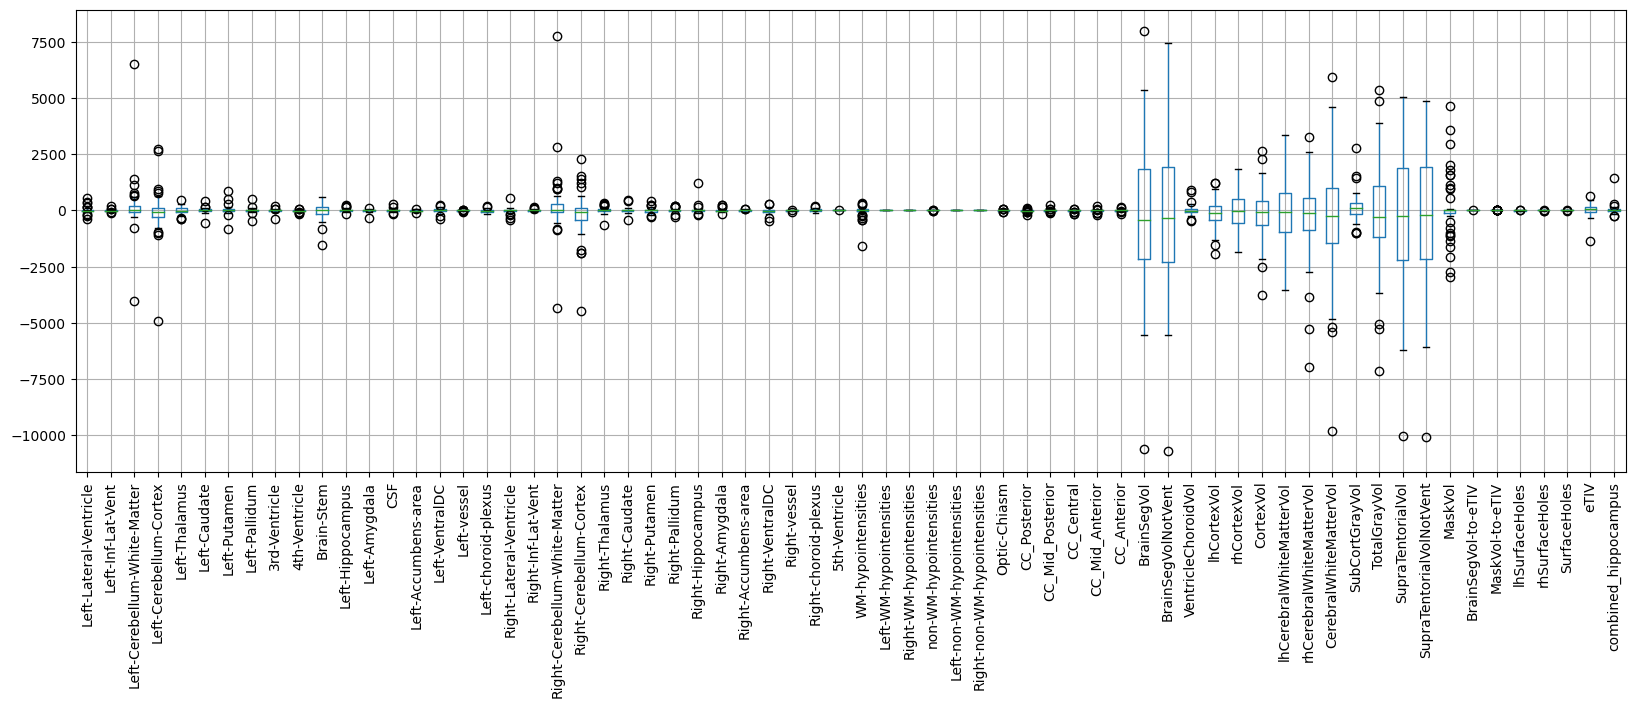

In [47]:
#for each column, get the stdev divided by the mean
for col in landman01_hickory_df.columns:
    #landman01_hickory_df[col] = landman01_hickory_df[col] / np.mean(landman01_hickory_df[col])
    #landman01_hickory_df[col] = landman01_hickory_df[col] / np.std(landman01_hickory_df[col])
    std = np.std(landman01_hickory_df[col])
    mean = np.abs(np.mean(landman01_hickory_df[col]))
    coeff_var = std / mean
    cohen_d = mean / std
    #print('Coefficient of variation for {}: {}'.format(col, coeff_var))
    print('Cohen\'s d for {}: {}'.format(col, cohen_d))

#make a series of boxplots for the differences between landman01 and hickory, with a boxplot for each roi
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplots(df, col):
    """
    Plot boxplots for the differences between landman01 and hickory
    """

    #create a new column that is the absolute value of the differences
    df['abs_diffs'] = df[col].abs()
    
    #create a boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='server', y='abs_diffs', data=df)
    plt.title('Differences between landman01 and hickory for {}'.format(col))
    plt.xlabel('Server')
    plt.ylabel('Absolute Differences')
    plt.show()

f,ax = plt.subplots(1, 1, figsize=(20, 6))

landman01_hickory_df.boxplot(ax=ax, rot=90)

## Now, we need to get all the singularity freesurfer runs

In [27]:
def get_server_hippocampus_df(root, server_name, singularity=False):

    if singularity:
        cmd = 'find {} -mindepth 3 -maxdepth 3 -name "singularity_freesurfer*{}*"'.format(root, server_name)
    else:
        cmd = 'find {} -mindepth 3 -maxdepth 3 -name "freesurfer*{}*"'.format(root, server_name)
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip().splitlines()

    #get only the freesurfer directories that succeeded
    print("Checking valid freesurfer directories...")
    valid_fs = [x for x in tqdm(res) if freesurfer_succeeded(x)]
    print("Found {} valid freesurfer directories out of {}".format(len(valid_fs), len(res)))

    #collect the hippocampus volumes
    print("Collecting hippocampus volumes...")
    hippocampus_volumes = collect_segmentation_volumes(valid_fs)

    return hippocampus_volumes

landsing = get_server_hippocampus_df(root, 'landman01', singularity=True)
hicksing = get_server_hippocampus_df(root, 'hickory', singularity=True)
visesing = get_server_hippocampus_df(root, 'viselab', singularity=True)

Checking valid freesurfer directories...


100%|██████████| 50/50 [00:05<00:00,  9.42it/s]


Found 50 valid freesurfer directories out of 50


100%|██████████| 50/50 [00:01<00:00, 49.88it/s]


Checking valid freesurfer directories...


...

100%|██████████| 50/50 [00:01<00:00, 44.66it/s]


Checking valid freesurfer directories...


100%|██████████| 50/50 [00:05<00:00,  9.12it/s]


Found 50 valid freesurfer directories out of 50


100%|██████████| 50/50 [00:01<00:00, 35.58it/s]


In [30]:
#combine the df
sing_dfs = [landsing, hicksing, visesing]

sing_comb = pd.concat(sing_dfs, ignore_index=True)
print(sing_comb.shape)

#get the combined hippocampus volumes
sing_comb['combined_hippocampus'] = sing_comb['Left-Hippocampus'] + sing_comb['Right-Hippocampus']

# create the server column
sing_comb['server'] = sing_comb['fs_dir'].apply(lambda x: x.split('_')[2])

(150, 68)


In [31]:
#get the pairwise differences
sing_diffs_df = get_pairwise_diffs(sing_comb)

In [32]:
print(sing_comb[sing_comb['sub']=='sub-341'])

         sub        ses                                       fs_dir  \
0    sub-341  ses-wave1  singularity_freesurfer7.2.0_landman01_run-1   
50   sub-341  ses-wave1    singularity_freesurfer7.2.0_hickory_run-1   
100  sub-341  ses-wave1    singularity_freesurfer7.2.0_viselab_run-1   

     Left-Lateral-Ventricle  Left-Inf-Lat-Vent  Left-Cerebellum-White-Matter  \
0                   13263.9              437.0                       14813.5   
50                  13263.9              437.0                       14813.5   
100                 13263.9              437.0                       14813.5   

     Left-Cerebellum-Cortex  Left-Thalamus  Left-Caudate  Left-Putamen  ...  \
0                   57058.5         6956.4        3378.2        5052.5  ...   
50                  57058.5         6956.4        3378.2        5052.5  ...   
100                 57058.5         6956.4        3378.2        5052.5  ...   

     SupraTentorialVolNotVent    MaskVol  BrainSegVol-to-eTIV  \
0       